In [1]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict, math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data_new_type as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [69]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\4-18-2.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() 
    replay_start_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() - 3
    print(replay_start_time, cwb_origin_time)
    print(datetime.fromtimestamp(replay_start_time))

1618755277.0 1618755280.0
2021-04-18 22:14:37


In [70]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

# variables #
#data
mqtt_data = "4.18//Alarms_026.json"
site_data = "4.18//Sites_026.json"
trigger_site = []
trigger_cwb = []
calculating_list = []
data_list = []
sp_site = ["S00049"]

frame_rate = 0.1 #10 frame/per second
s_radius = 0.045 
p_radius = 0.055

#zero point
origin_x = 119 
origin_y = 21.8 
delta_x = 3.3 
delta_y = 3.7

t_size = 20 #text size

cbw = 2.3 #county_boundary_width
tbw = 0.5 #town_boundary_width

#eq_data
data = ld.load_data(mqtt_data)
replay_end_time = datetime.strptime(data[-1]["Date"]+" "+data[-1]["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp() #data.iloc[-1, 0].timestamp()
replay_loop = round((replay_end_time-replay_start_time)/frame_rate)
print(replay_end_time)


#site_data
site_df = ld.load_site(site_data)
site_df["Calculate_Time"] = ""
#print(site_df)

for index, row in site_df.iterrows():
    if row["Site_ID"] in sp_site:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=1)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp

    else:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=3)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp
#print(site_df)
site_geo = gpd.GeoDataFrame(site_df, geometry=gpd.points_from_xy(site_df.Site_Lon, site_df.Site_Lat))


#for ind, row in site_geo.iterrows():
    #print(ind,row["Site_ID"])
#Datetime = list(set(site_df.Datetime.tolist()))
#Trigger_Time = list(set(site_df.Trigger_Time.tolist()))
#Datetime.sort()
#Trigger_Time.sort()

#site_times = {
#        "Datetime":Datetime,
#        "Trigger_Time":Trigger_Time
#}



1618755357.613


2021-04-18 22:14:37.100000


C:\Users\USER\Anaconda3\envs\map_geopandas\lib\site-packages\geopandas\plotting.py:487: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,


2021-04-18 22:14:37.200000
2021-04-18 22:14:37.300000


KeyboardInterrupt: 

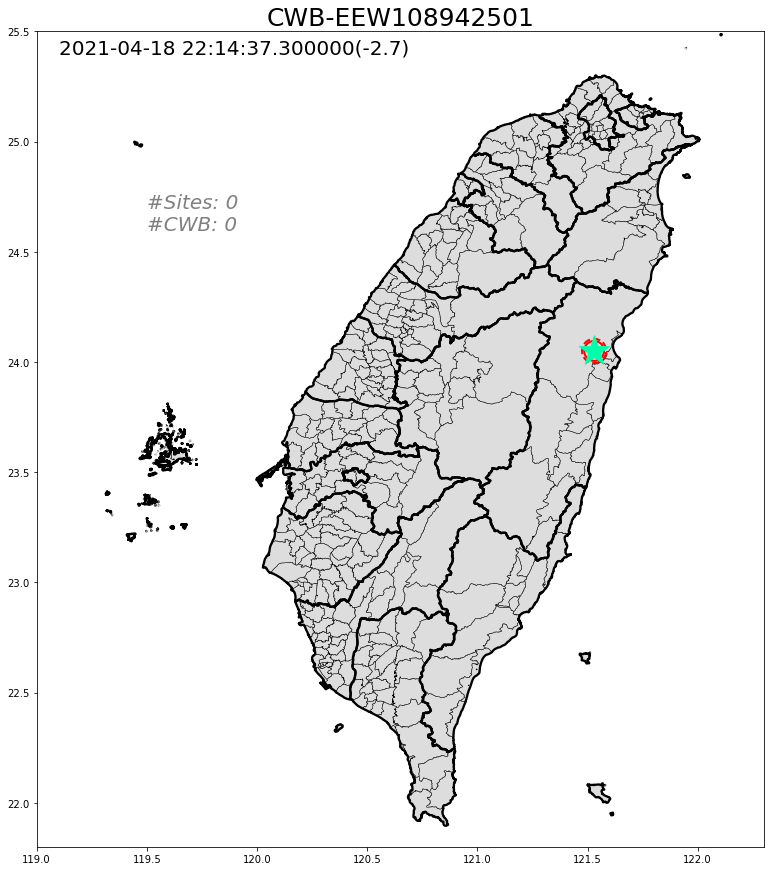

In [75]:
#plotting eq data
color_map = [
        '#C4FBE2',
        '#26FF0B',
        '#FFFE0B',
        '#FF810B',
        '#FF550B',
        '#AC1F14',
        '#A92700',
        '#983476',
        '#BB20D9'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#map init
f, axes = plt.subplots(figsize=(15,15))
axes.set_title(Identifier, fontsize=25)
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=cbw, zorder=2)  #draw counties
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=tbw, zorder=1)     #draw towns
    
#set pic location
minx, miny, maxx, maxy = (origin_x, origin_y, origin_x + delta_x, origin_y + delta_y)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
#event_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))
replay_time = datetime.fromtimestamp(replay_start_time)

#TextBoxes
axes_time = axes.text(minx+0.1, maxy-0.1, replay_time, size=t_size)
axes_site_count = axes.text(119.5, 24.7, "#Sites: "+str(len(trigger_site)), size=t_size, style='italic', c="gray")
axes_cwb_count = axes.text(119.5, 24.6, "#CWB: "+str(len(trigger_cwb)), size=t_size, style='italic', c="gray")


#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)

#before_event_process
#while replay_time <= datetime.fromtimestamp(cwb_origin_time):
    #replay_time += timedelta(seconds=frame_rate)
    #print(replay_time)
    #replay_time_str = replay_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
    #axes.texts[-3].set_text((replay_time_str.replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
        
    #print(texts)
    #axes.plot()
    #axes.figure.savefig(replay_time_str+".png")
    
for time in range(replay_loop):
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    replay_time += timedelta(seconds=frame_rate)
    print(replay_time)
    
    
    #繪製計算中站台
    #calculating_site = site_geo.loc[replay_time >= site_geo["Calculate_Time"]]
    #for index, row in site_geo.iterrows():
        
        #若播放時間大於站台計算時間
        #if replay_time >= row["Calculate_Time"]:
            #if row["Site_ID"] not in calculating_list:
                #calculating_list.append(row["Site_ID"])                
                #calculating_site_plot = site_geo.iloc[[index], :]
                #print(calculating_site_plot)
                #calculating_site_plot.plot(ax=axes, color="#3BFF3A", edgecolor="black", marker=7, markersize=250, zorder=3)
                #axes.figure.savefig(str(time)+"C"+".png")

                
        #若播放時間大於站台觸發時間
        #if replay_time >= row["Trigger_Time"] and row["Site_ID"] in calculating_list:
            #if row["Site_ID"] not in trigger_site:
                #trigger_site.append(row["Site_ID"])
                #trigger_site_plot = site_geo.iloc[[index], :]
                #trigger_site_plot.plot(ax=axes, color="#FFFB00", edgecolor="black", marker=7, markersize=250, zorder=3)"""
        
        
    #若播放時間大於現地預警時間
    for item in data:
        if replay_time >= datetime.strptime(item["Date"]+" "+item["Time"], "%Y-%m-%d %H:%M:%S.%f"):
            #print("data")
            for Area in item["Areas"]:
                #print(Area)
                AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGAx"], ld.pga_to_level(float(Area["PGAx"]))))
                if Area["Source"] not in trigger_cwb and Area["Source"].startswith("CWB"):
                    trigger_cwb.append(Area["Source"])
                    axes.texts[-1].set_text("#CWB: "+str(len(trigger_cwb)))

                else:
                    continue
            #print(AreaDetail)
            data1 = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
            data1 = data1.sort_values(by=["AreaCode", "PGA"])
            for i in range(len(data1)):
                draw = town[town.TOWNCODE == data1.loc[i, "AreaCode"]]
                draw = draw.assign(Intensity = data1.loc[i, "Intensity"])
                draw_area = draw_area.append(draw)
                
        p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
        axes.add_patch(p_circle)
        s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
        axes.add_patch(s_circle)
        draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
        axes.texts[-3].set_text((str(replay_time).replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
        axes.figure.savefig(str(replay_time).replace(":", "_")+".png")

        p_circle.remove()
        s_circle.remove()

    #if calculating_site.empty == False:
        #site_id = calculating_site["Site_ID"].values[0]
        #print(site_id)
        #if site_id in calculating_list:
            #print(site_id, "calculating...")
            #continue
        #else:
            #calculating_list.append(calculating_site["Site_ID"].values[0])
            #print(calculating_list)
            #calculating_site.plot(ax=axes, color="#3BFF3A", edgecolor="black", marker=7, markersize=250, zorder=3)
            
    #else:
        #continue